# Early Prediction of Crop Yield Using Climate and Agricultural Inputs

This notebook builds a machine learning model to predict crop yield and explains the influence of climate and agricultural factors.

## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Dataset

In [2]:

df = pd.read_csv("yield_df.csv")
df.head()


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485,121.0,16.37


## 3. Data Understanding

In [3]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  int64  
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 1.7+ MB


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


## 4. Data Cleaning

In [4]:

df.drop('Unnamed: 0', axis=1, inplace=True)
df.isnull().sum()


,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


## 5. Encode Categorical Features

In [5]:

label_cols = ['Area', 'Item']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])
df.head()


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,1990,36613,1485,121.0,16.37
1,0,3,1990,66667,1485,121.0,16.37
2,0,4,1990,23333,1485,121.0,16.37
3,0,5,1990,12500,1485,121.0,16.37
4,0,6,1990,7000,1485,121.0,16.37


## 6. Feature Engineering

In [6]:

df['rainfall_temp_interaction'] = df['average_rain_fall_mm_per_year'] * df['avg_temp']
df['pesticide_per_temp'] = df['pesticides_tonnes'] / (df['avg_temp'] + 1)
df.head()


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,rainfall_temp_interaction,pesticide_per_temp
0,0,1,1990,36613,1485,121.0,16.37,24309.45,6.966033
1,0,3,1990,66667,1485,121.0,16.37,24309.45,6.966033
2,0,4,1990,23333,1485,121.0,16.37,24309.45,6.966033
3,0,5,1990,12500,1485,121.0,16.37,24309.45,6.966033
4,0,6,1990,7000,1485,121.0,16.37,24309.45,6.966033


## 7. Define Features and Target

In [7]:

X = df.drop('hg/ha_yield', axis=1)
y = df['hg/ha_yield']


## 8. Train-Test Split and Scaling

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 9. Model Training

In [9]:

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


## 10. Model Evaluation (Outputs)

In [10]:

def evaluate(y_true, y_pred, name):
    print(name)
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))
    print("-"*40)

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")


Linear Regression
MAE: 62425.56327299435
RMSE: 81310.93810336612
R2 Score: 0.0885349266130715
----------------------------------------
Random Forest
MAE: 4054.102986959344
RMSE: 10767.813905790108
R2 Score: 0.9840155693867287
----------------------------------------


## 11. Sample Predictions (OUTPUT)

In [11]:

pred_df = pd.DataFrame({
    'Actual_Yield': y_test.values[:10],
    'Predicted_Yield': rf_pred[:10]
})
pred_df


,Actual_Yield,Predicted_Yield
0,69220,71478.713333
1,20000,24150.100000
2,51206,51625.890000
3,166986,162822.293333
4,56319,58210.013333
5,26163,26163.000000
6,30708,30523.133333
7,109771,111082.583333
8,241650,237365.236667
9,47500,46000.910000


## 12. Feature Importance

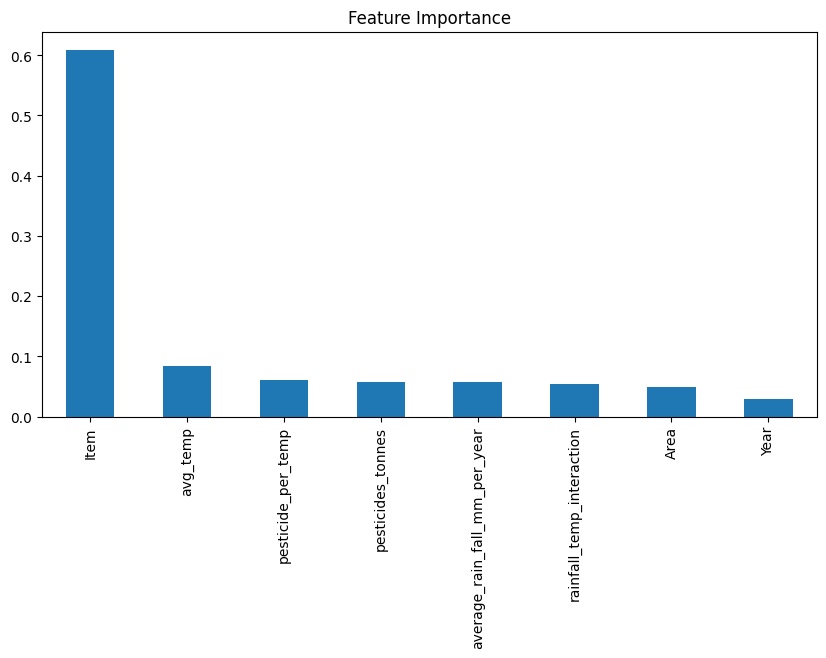

In [12]:

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()


## 13. Conclusion
- Random Forest outperforms Linear Regression
- Climate interaction features improve prediction
- Model is suitable for early agricultural decision support